So we have a pretty good model but now we want to perturb it a bit to see if we can do better ie get a better model in terms of out of sample rmse.

In [ ]:
library(IRdisplay)

# Packages are now installed via conda, just load them
library(smooth)
library(forecast)

fdf <- read.csv("data/fluview_clean/ilinet_final.csv")



# so now we can perturb and look for the best rmse
source("find_best_rmse.r")
# our data transformations
source("transformations.R")

results <- out_of_sample_rmse(y, orders = list(ar=c(1,0,1), i=c(1,1,0), ma=c(1,0,1)))


## VARMA and msts

Warning message in adf.test(x):
“p-value smaller than printed p-value”
Warning message in adf.test(x):
“p-value smaller than printed p-value”
Warning message in adf.test(x):
“p-value smaller than printed p-value”


[1] "ADF test p-values (stationarity):"
$non_ilitotal
[1] 0.01

$num_of_providers
[1] 0.01

$ilitotal
[1] 0.01



Warning message in adf.test(x):
“p-value smaller than printed p-value”
Warning message in adf.test(x):
“p-value smaller than printed p-value”
Warning message in adf.test(x):
“p-value smaller than printed p-value”


[1] "ADF test p-values after seasonal differencing (lag 52):"
$non_ilitotal
[1] 0.01

$num_of_providers
[1] 0.01

$ilitotal
[1] 0.01



Warning message in adf.test(x):
“p-value smaller than printed p-value”
Warning message in adf.test(x):
“p-value smaller than printed p-value”
Warning message in adf.test(x):
“p-value smaller than printed p-value”


[1] "Final ADF test p-values:"
$non_ilitotal
[1] 0.01

$num_of_providers
[1] 0.01

$ilitotal
[1] 0.01

[1] "Cross-correlations at lag 19:"


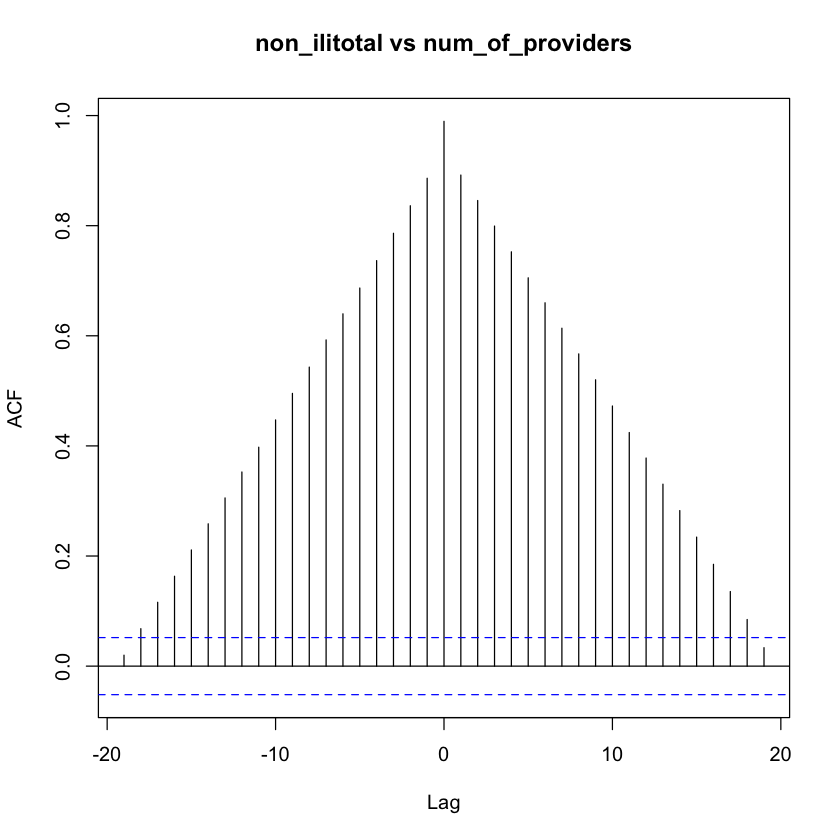

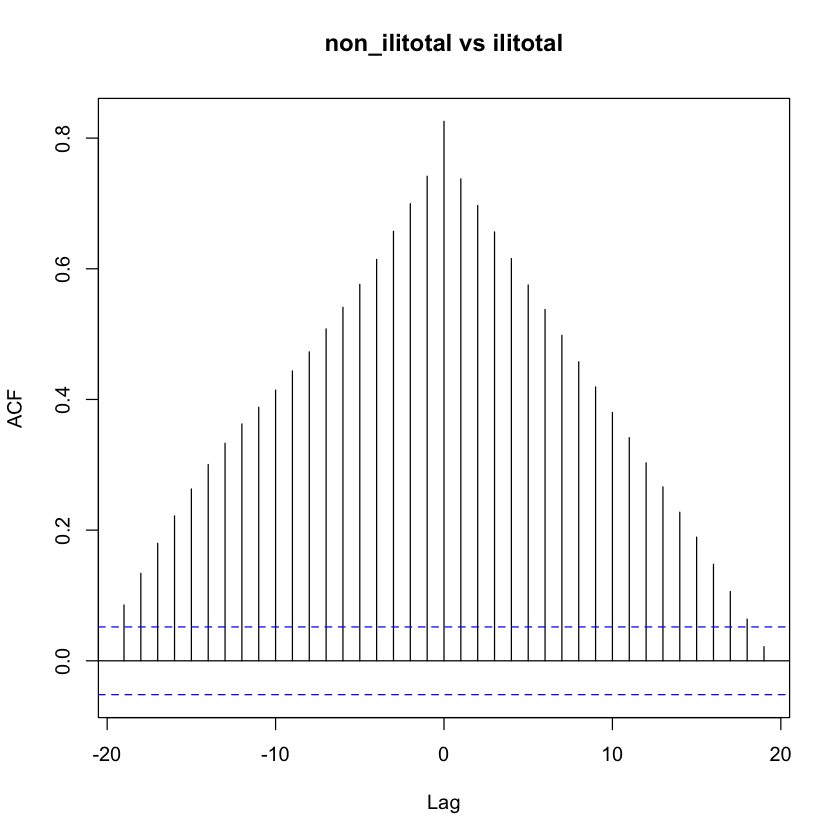

[1] "Johansen cointegration test:"

###################### 
# Johansen-Procedure # 
###################### 

Test type: trace statistic , with linear trend 

Eigenvalues (lambda):
[1] 0.043652238 0.040797419 0.008992809

Values of teststatistic and critical values of test:

           test 10pct  5pct  1pct
r <= 2 |  13.37  6.50  8.18 11.65
r <= 1 |  75.02 15.66 17.95 23.52
r = 0  | 141.07 28.71 31.52 37.22

Eigenvectors, normalised to first column:
(These are the cointegration relations)

                    non_ilitotal.l2 num_of_providers.l2 ilitotal.l2
non_ilitotal.l2            1.000000            1.000000   1.0000000
num_of_providers.l2       -1.825969           -4.317360  -1.6960510
ilitotal.l2                0.130816            1.850398  -0.3798424

Weights W:
(This is the loading matrix)

                   non_ilitotal.l2 num_of_providers.l2 ilitotal.l2
non_ilitotal.d          -0.4369796          0.07348038  0.02531177
num_of_providers.d      -0.2107297          0.04207500  0

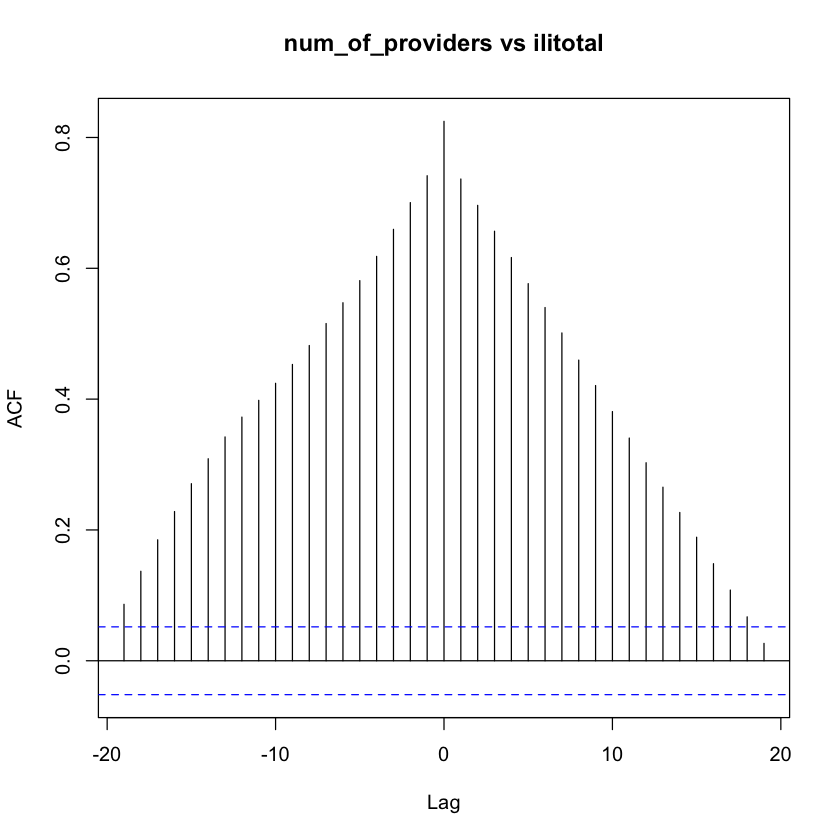

In [7]:
# VARMA model for non_ilitotal, num_of_providers, and ili_total
# Taking into account differencing and seasonal lags at 19 and 52

library(MTS)  
library(urca)  
library(tseries)  
library(forecast)
library(vars)

df <- read.csv("data/fluview_clean/ilinet_final.csv", row.names = 1)
vars_data <- df[, c("non_ilitotal", "num_of_providers", "ilitotal")]
vars_data <- na.omit(vars_data) 

adf_tests <- lapply(vars_data, function(x) adf.test(x)$p.value)
print("ADF test p-values (stationarity):")
print(adf_tests)

# Apply seasonal differencing at lag 52 (weekly seasonality)
vars_seasonal_diff <- apply(vars_data, 2, function(x) diff(x, lag = 52))
vars_seasonal_diff <- as.data.frame(vars_seasonal_diff)

# Check stationarity after seasonal differencing
adf_tests_seasonal <- lapply(vars_seasonal_diff, function(x) adf.test(x)$p.value)
print("ADF test p-values after seasonal differencing (lag 52):")
print(adf_tests_seasonal)

# If still not stationary, apply first differencing
if(any(unlist(adf_tests_seasonal) > 0.05)) {
  vars_diff <- apply(vars_seasonal_diff, 2, diff)
  vars_diff <- as.data.frame(vars_diff)
  print("Applied additional first differencing")
} else {
  vars_diff <- vars_seasonal_diff
}

# Final stationarity check
adf_tests_final <- lapply(vars_diff, function(x) adf.test(x)$p.value)
print("Final ADF test p-values:")
print(adf_tests_final)

# Cross-correlation analysis to identify lags
print("Cross-correlations at lag 19:")
ccf(vars_diff$non_ilitotal, vars_diff$num_of_providers, lag.max = 19, main = "non_ilitotal vs num_of_providers")
ccf(vars_diff$non_ilitotal, vars_diff$ilitotal, lag.max = 19, main = "non_ilitotal vs ilitotal")
ccf(vars_diff$num_of_providers, vars_diff$ilitotal, lag.max = 19, main = "num_of_providers vs ilitotal")

# Check for cointegration
coint_test <- ca.jo(vars_data, type = "trace", K = 2)
print("Johansen cointegration test:")
print(summary(coint_test))

# Fit VAR model on differenced data
var_model <- vars::VAR(vars_diff, p = 1, type = "const")
print("VAR model summary:")
print(summary(var_model))

# Note: SARIMA with exogenous variables section removed due to data length mismatch issues
# The differencing operations change data length, making it incompatible with original xreg matrices
# Consider using Granger causality tests or impulse response analysis instead
print("VAR model analysis complete")

I want now a model that does a 1 step ahaed rolling forcast for age_5_24 using varma and the other variables age_0_4, age_25_49, age_50_64,age_65. be sure to use the split data funciton to get each of these variables and put remove.missing =T so that we only get te variables when they exist


[1] "Data loaded. Checking dimensions:"
[1] "age_5_24 train: 1117 holdout: 104"
[1] "age_0_4 train: 1117 holdout: 104"
[1] "Min train length: 1117"
[1] "Min holdout length: 104"
[1] "Training observations (after NA removal): 751"
[1] "Holdout observations (after NA removal): 104"
[1] "Starting 1-step ahead rolling forecast (LAGGED-ONLY) with 104 steps"
[1] "Completed step 10 of 104"
[1] "Completed step 20 of 104"
[1] "Completed step 30 of 104"
[1] "Completed step 40 of 104"
[1] "Completed step 50 of 104"
[1] "Completed step 60 of 104"
[1] "Completed step 70 of 104"
[1] "Completed step 80 of 104"
[1] "Completed step 90 of 104"
[1] "Completed step 100 of 104"
[1] "Number of successful forecasts: 104"
[1] "RMSE for age_5_24 (Lagged-Only, variance-corrected): 5803.80550810836"
[1] "Final RMSE: 5803.80550810836"


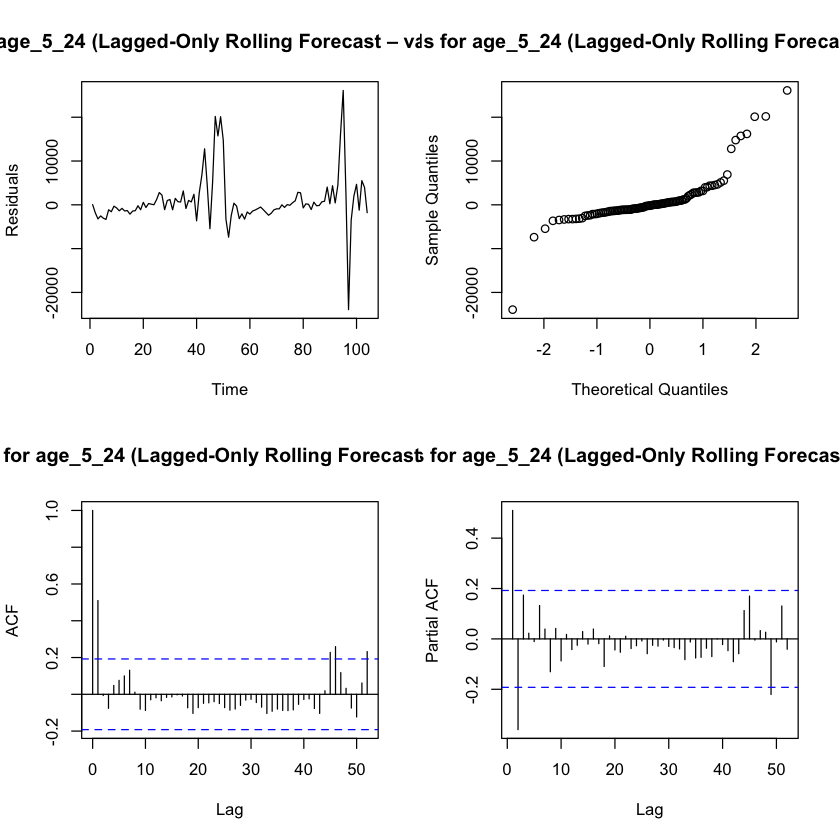

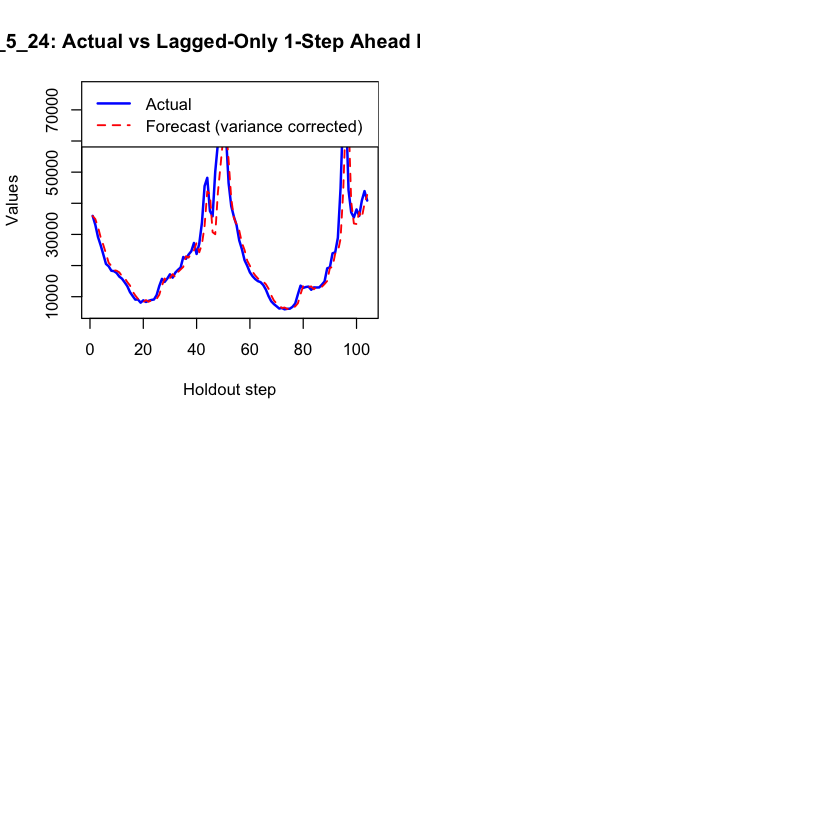

In [31]:
library(MTS)
source("./df.R")
source("./print.R")
source("transformations.R")

# Load data
df <- read.csv("data/fluview_clean/ilinet_final.csv", row.names = 1)
old_df <- read.csv("data/fluview_clean/ilinet_clean.csv")

# Get age_5_24 (target variable) - apply log1p transformation
age_5_24_data <- split_data((df$age_5_24), remove.missing = TRUE)

# Get predictor variables - apply log1p transformation
age_0_4_data <- split_data((df$age_0_4), remove.missing = TRUE)

# Get age_25_49 and age_50_64 from old_df (for when age_25_64 is missing)
age_25_49_ts <- ts(old_df$age_25_49, frequency = 52, start = c(1997, 40))
age_25_49_data <- split_data((age_25_49_ts), remove.missing = TRUE)

age_50_64_ts <- ts(old_df$age_50_64, frequency = 52, start = c(1997, 40))
age_50_64_data <- split_data((age_50_64_ts), remove.missing = TRUE)

# Get age_65
age_65_data <- split_data((df$age_65), remove.missing = TRUE)

print("Data loaded. Checking dimensions:")
print(paste("age_5_24 train:", length(age_5_24_data$train), "holdout:", length(age_5_24_data$holdout)))
print(paste("age_0_4 train:",  length(age_0_4_data$train),  "holdout:", length(age_0_4_data$holdout)))

# Align all series to the common minimum length so rows correspond to the same time points
min_train_length <- min(
  length(age_5_24_data$train), length(age_0_4_data$train),
  length(age_25_49_data$train), length(age_50_64_data$train),
  length(age_65_data$train)
)
min_holdout_length <- min(
  length(age_5_24_data$holdout), length(age_0_4_data$holdout),
  length(age_25_49_data$holdout), length(age_50_64_data$holdout),
  length(age_65_data$holdout)
)

print(paste("Min train length:", min_train_length))
print(paste("Min holdout length:", min_holdout_length))

train_data <- na.omit(as.data.frame(list(
  age_5_24  = age_5_24_data$train[1:min_train_length],
  age_0_4   = age_0_4_data$train[1:min_train_length],
  age_25_49 = age_25_49_data$train[1:min_train_length],
  age_50_64 = age_50_64_data$train[1:min_train_length],
  age_65    = age_65_data$train[1:min_train_length]
)))

holdout_data <- na.omit(as.data.frame(list(
  age_5_24  = age_5_24_data$holdout[1:min_holdout_length],
  age_0_4   = age_0_4_data$holdout[1:min_holdout_length],
  age_25_49 = age_25_49_data$holdout[1:min_holdout_length],
  age_50_64 = age_50_64_data$holdout[1:min_holdout_length],
  age_65    = age_65_data$holdout[1:min_holdout_length]
)))

n_train   <- nrow(train_data)
n_holdout <- nrow(holdout_data)

print(paste("Training observations (after NA removal):", n_train))
print(paste("Holdout observations (after NA removal):", n_holdout))

if (n_train < 10 || n_holdout < 1) {
  stop("Insufficient data after alignment and NA removal")
}

# ---------------------------------------------------------------------------
# 1-step ahead rolling forecast using LAGGED-ONLY regression
#
# Model:  age_5_24(t) ~ age_5_24(t-1) + age_0_4(t-1) + age_25_49(t-1)
#                     + age_50_64(t-1) + age_65(t-1)
#
# All predictors are lag-1, so nothing from time t is used — causally valid.
#
# Bias correction for log scale:
#   When we back-transform with expm1(), the conditional expectation on the
#   original scale is approximately exp(mu + sigma^2/2) - 1, not expm1(mu).
#   We therefore add sigma^2/2 (from the training residuals) to the
#   log-scale forecast before back-transforming.  This uses only information
#   available at forecast time, so there is no data leakage.
# ---------------------------------------------------------------------------

# Initialise storage as NA so that failed steps are identifiable
forecasts_log <- rep(NA_real_, n_holdout)   # log-scale forecast (corrected)
actuals_log   <- rep(NA_real_, n_holdout)   # log-scale actuals

print(paste("Starting 1-step ahead rolling forecast (LAGGED-ONLY) with", n_holdout, "steps"))

for (i in seq_len(n_holdout)) {

  # Expand training window: original train + already-observed holdout rows
  current_train <- if (i == 1) train_data else rbind(train_data, holdout_data[seq_len(i - 1), ])
  current_train <- na.omit(current_train)
  n_cur <- nrow(current_train)

  if (n_cur < 6) {          # need at least a handful of lagged pairs
    warning(paste("Step", i, ": insufficient rows (", n_cur, "), skipping."))
    next
  }

  tryCatch({
    # Build lagged dataset: row k gives (Y(t), X(t-1)) for t = 2 … n_cur
    lagged_train <- data.frame(
      age_5_24_target = current_train$age_5_24[2:n_cur],
      age_5_24_lag1   = current_train$age_5_24[1:(n_cur - 1)],
      age_0_4_lag1    = current_train$age_0_4[1:(n_cur - 1)],
      age_25_49_lag1  = current_train$age_25_49[1:(n_cur - 1)],
      age_50_64_lag1  = current_train$age_50_64[1:(n_cur - 1)],
      age_65_lag1     = current_train$age_65[1:(n_cur - 1)]
    )

    lm_fit <- lm(
      age_5_24_target ~ age_5_24_lag1 + age_0_4_lag1 +
        age_25_49_lag1 + age_50_64_lag1 + age_65_lag1,
      data = lagged_train
    )

    # Variance-based bias correction for log scale:
    # sigma^2 estimated from in-window residuals
    sigma2 <- mean(residuals(lm_fit)^2)   # MSE of training residuals

    # Predictors for step i are the LAST observed row (time t-1 relative to target)
    last_obs <- current_train[n_cur, ]
    pred_data <- data.frame(
      age_5_24_lag1  = last_obs$age_5_24,
      age_0_4_lag1   = last_obs$age_0_4,
      age_25_49_lag1 = last_obs$age_25_49,
      age_50_64_lag1 = last_obs$age_50_64,
      age_65_lag1    = last_obs$age_65
    )

    # Log-scale point forecast + variance correction (smearing estimator)
    mu_hat <- predict(lm_fit, newdata = pred_data)
    forecasts_log[i] <- mu_hat + 0.5 * sigma2   # corrected log-scale forecast

    actuals_log[i] <- holdout_data$age_5_24[i]

    if (i %% 10 == 0) print(paste("Completed step", i, "of", n_holdout))

  }, error = function(e) {
    warning(paste("Error at step", i, ":", conditionMessage(e)))
  })
}

# ---------------------------------------------------------------------------
# Back-transform and evaluate
# ---------------------------------------------------------------------------

valid_idx        <- !is.na(forecasts_log) & !is.na(actuals_log)
forecasts_clean  <- forecasts_log[valid_idx]
actuals_clean    <- actuals_log[valid_idx]

# Back-transform to original scale
actual_original   <- expm1(actuals_clean)
forecast_original <- expm1(forecasts_clean)   # variance correction already applied

# RMSE on original scale
rmse_age_5_24_lagged_only <- sqrt(mean((actual_original - forecast_original)^2, na.rm = TRUE))

print(paste("Number of successful forecasts:", sum(valid_idx)))
print(paste("RMSE for age_5_24 (Lagged-Only, variance-corrected):", rmse_age_5_24_lagged_only))

# Residual diagnostics
if (sum(valid_idx) > 0) {
  residuals_final <- actual_original - forecast_original
  plotresidues(residuals_final, "age_5_24 (Lagged-Only Rolling Forecast – variance corrected)")

  plot(actual_original, type = "l", col = "blue", lwd = 2,
       main = "age_5_24: Actual vs Lagged-Only 1-Step Ahead Forecast",
       ylab = "Values", xlab = "Holdout step",
       ylim = range(c(actual_original, forecast_original), na.rm = TRUE) + c(-100, 100))
  lines(forecast_original, col = "red", lty = 2, lwd = 1.5)
  legend("topleft",
         legend = c("Actual", "Forecast (variance corrected)"),
         col    = c("blue", "red"),
         lty    = c(1, 2), lwd = c(2, 1.5))
}

# Store for downstream use
age_5_24_lagged_only_forecast <- forecast_original
age_5_24_lagged_only_rmse     <- rmse_age_5_24_lagged_only
print(paste("Final RMSE:", age_5_24_lagged_only_rmse))

# Modelling with arima

## Single variable prediction for ilitotal
Specifically we are just using the ilitotals previous values to predict it.

In [53]:
source("./df.R")
source("find_best_rmse.r")
source("./print.R")
df <- read.csv("data/fluview_clean/ilinet_final.csv")


ilitotal_model <- find_best_rmse_out_of_sample(
  df$ilitotal,
  initial_orders = list(ar=c(2, 3, 2), i=c(0, 1, 0), ma=c(3, 1, 2)),
  perturbation = 2,
  iterations = 1
)
ilitotal_holdout <- split_data(df$ilitotal)$holdout
rmse <- sqrt(mean((expm1(ilitotal_holdout) - ilitotal_model$best_fc)^2))
print_rmse(rmse, "ilitotal", c("ili_total"))
ilitotal_fc <- ilitotal_model$best_fc

Complete:  100 % Best Orders: ar=c(2, 3, 2), i=c(0, 1, 0), ma=c(3, 1, 2) Best RMSE so far: 8997.34358513501 


[1] "RMSE: 8997.34358513501 for variable: ilitotal with predictors: ili_total"


In [62]:
ilitotal_model$best_orders

format_msarima <- function(best_orders) {
  paste0("MS ARIMA(", best_orders$ar[1], ",", 
         best_orders$i[1], ",", 
         best_orders$ma[1], ")(",
         best_orders$ar[3], ",", 
         best_orders$i[3], ",", 
         best_orders$ma[3], ")_{19}(",
         best_orders$ar[2], ",", 
         best_orders$i[2], ",", 
         best_orders$ma[2], ")_{52}"
         
         )
}

format_msarima(ilitotal_model$best_orders)


$ar
[1] 2 3 2

$i
[1] 0 1 0

$ma
[1] 3 1 2

[1] "MS ARIMA(2,0,3)(2,0,2)_{19}(3,1,1)_{52}"

### Computation to generalise calling find find_best_rmse_out_of_sample for any variable in df

In [ ]:

plotresidues <- function(residuals, name) {
  par(mfrow=c(2,2))
  plot(residuals, type='l',main=paste("Residuals of", name), ylab="Residuals", xlab="Time")
  qqnorm(residuals, main=paste("QQ Plot of Residuals for", name))
  acf(residuals, main=paste("ACF of Residuals for", name),lag.max = 52)
  pacf(residuals, main=paste("PACF of Residuals for", name),lag.max = 52)
}
get_it <- function(name,initial_orders = list(ar = c(2, 1, 0), i = c(0, 1, 0), ma = c(1, 0, 0)), perturbation = 1, iterations = 50,inverse_transformation=expm1,df) {
  df <- read.csv("data/fluview_clean/ilinet_final.csv")
  fc <- find_best_rmse_out_of_sample(
    df[[name]],
    initial_orders = initial_orders,
    perturbation = perturbation,
    iterations = iterations,
    inverse_transformation = inverse_transformation
  )
  residuals  <-inverse_transformation(split_data(df[[name]])$holdout)-fc$best_fc
  plotresidues(residuals, name)
  return(fc)
}

## Computing the different age groups
Note we write these as seperate cells so that we can avoid rerunning all of them if we only need to fix one estimation.

Complete:  100 % Best Orders: ar=c(5, 2, 0), i=c(1, 0, 0), ma=c(4, 2, 0) Best RMSE so far: 1890.60777465033 


[1] "MS ARIMA(5,1,4)(0,0,0)_{19}(2,0,2)_{52}"

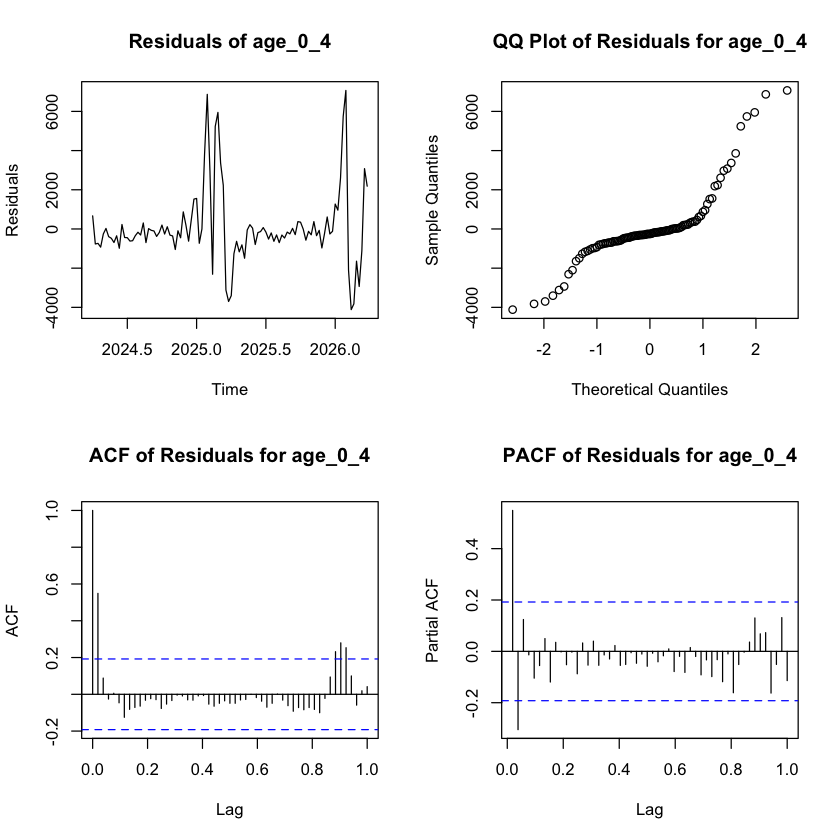

In [69]:
initial_orders_age_0_4 = list(ar=c(5, 2, 0), i=c(1, 0, 0), ma=c(4, 2, 0))

fc_age_0_4 <- get_it("age_0_4", initial_orders = initial_orders_age_0_4, perturbation = 2,iterations = 1)
fc_age_0_4_fc <- fc_age_0_4$best_fc
fc_age_0_4_fit <-fc_age_0_4$fit
format_msarima(fc_age_0_4$best_orders)

In [115]:
initial_orders_age_5_24 = list(ar=c(2, 1, 2), i=c(0, 1, 0), ma=c(3, 1, 2))
fc_age_5_24 <- get_it("age_5_24", initial_orders = initial_orders_age_5_24, perturbation = 4, iterations = 1)
# we use this so if it is taking to long we can stop the output and still have our forecast!
fc_age_5_24_values <- fc_age_5_24$best_fc
fc_age_5_24_fit <- fc_age_5_24$fit

Complete:  1 % 


In [ ]:
initial_orders_age_25_64 = list(ar=c(1, 2, 1), i=c(0, 0, 1), ma=c(1, 1, 0))
fc_age_25_64 <- get_it("age_25_64", initial_orders = initial_orders_age_25_64,perturbation = 2,iterations = 5)
# we use this so if it is taking to long we can stop the output and still have our forecast!
fc_age_25_64_values <- fc_age_25_64$best_fc
fc_age_25_64_fit <- fc_age_25_64$fit

Complete:  100 % Best Orders: ar=c(1, 2, 2), i=c(1, 0, 1), ma=c(2, 1, 0) Best RMSE so far: 2445.48786686041 


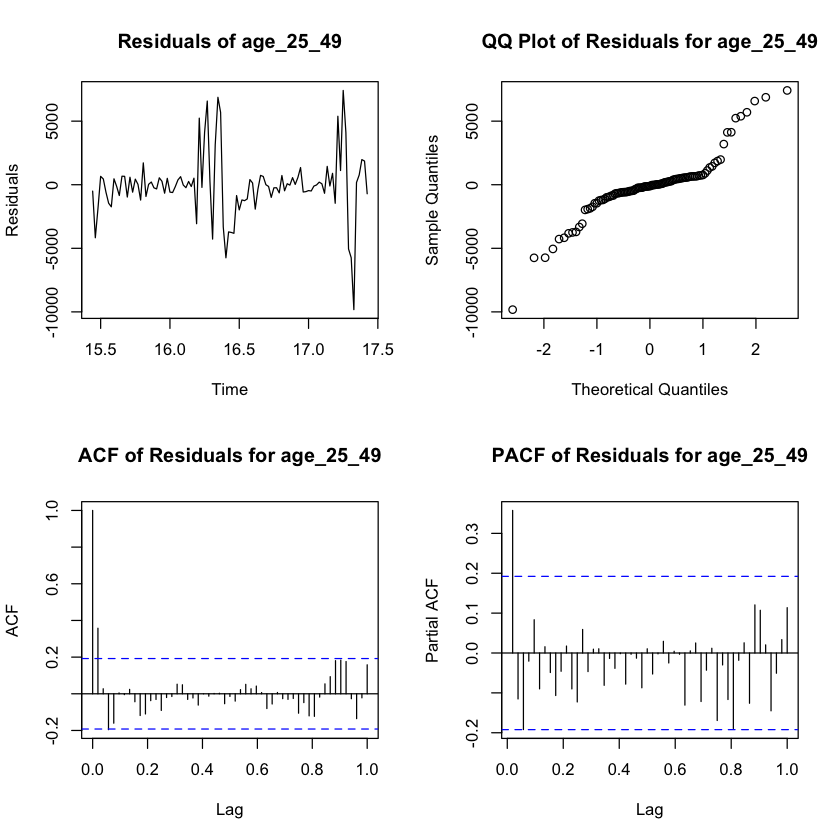

In [72]:

old_df <- read.csv("data/fluview_clean/ilinet_clean.csv")
age_25_49 <- ts(old_df$age_25_49, frequency = 52,start = c(1997, 40))[is.na(old_df$age_25_64)]
data_age_25_49 <- split_data(logp1(age_25_49),start=start(age_25_49))


initial_orders_age_25_49 = list(ar=c(1, 2, 2), i=c(1, 0, 1), ma=c(2, 1, 0))
fc_age_25_49 <- find_best_rmse_out_of_sample(data_age_25_49$ts_obj, initial_orders = initial_orders_age_25_49,perturbation = 2,iterations = 1)
# we use this so if it is taking to long we can stop the output and still have our forecast!
fc_age_25_49_values <- fc_age_25_49$best_fc
fc_age_25_49_fit <- fc_age_25_49$fit
residuals  <-expm1(data_age_25_49$holdout)-fc_age_25_49$best_fc
plotresidues(residuals, "age_25_49")


Complete:  100 % Best Orders: ar=c(1, 2, 2), i=c(1, 0, 1), ma=c(2, 1, 0) Best RMSE so far: 1153.19795767203 


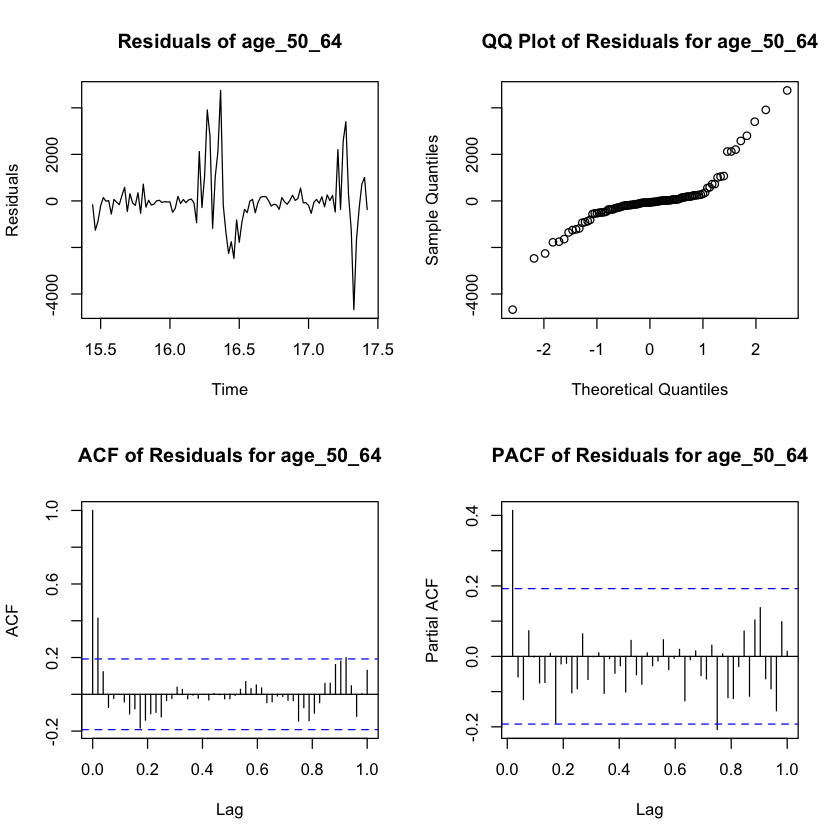

In [73]:
age_50_64 <- ts(old_df$age_50_64, frequency = 52,start = c(1997, 40))[is.na(old_df$age_25_64)]
data_age_50_64 <- split_data(logp1(age_50_64),start=start(age_50_64))

initial_orders_age_50_64 = list(ar=c(1, 2, 2), i=c(1, 0, 1), ma=c(2, 1, 0))
fc_age_50_64 <- find_best_rmse_out_of_sample(data_age_50_64$ts_obj, initial_orders = initial_orders_age_50_64,perturbation = 2,iterations = 1)
# we use this so if it is taking to long we can stop the output and still have our forecast!
fc_age_50_64_values <- fc_age_50_64$best_fc
fc_age_50_64_fit <- fc_age_50_64$fit
residuals  <-expm1(data_age_50_64$holdout)-fc_age_50_64$best_fc
plotresidues(residuals, "age_50_64")


Complete:  100 % Best Orders: ar=c(1, 1, 0), i=c(0, 1, 0), ma=c(0, 1, 1) Best RMSE so far: 1515.54718072021 


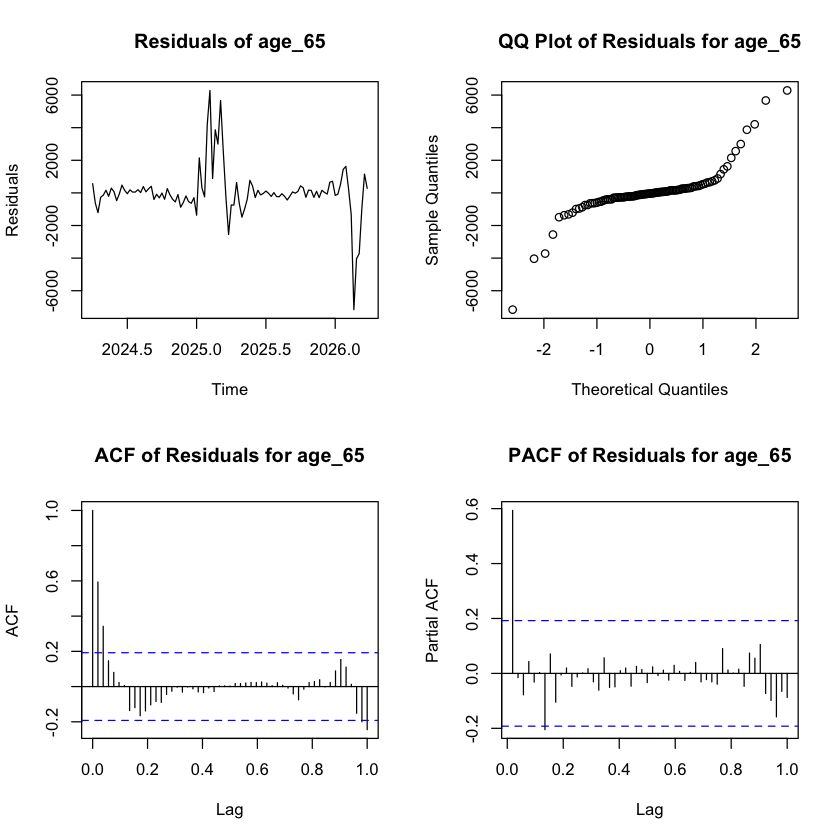

In [74]:
initial_orders_age_65 = list(ar=c(1, 1, 0), i=c(0, 1, 0), ma=c(0, 1, 1))
fc_age_65 <- get_it("age_65", initial_orders = initial_orders_age_65,perturbation = 2, iterations = 5)
fc_age_65_values <- fc_age_65$best_fc
fc_age_65_fit <- fc_age_65$fit
# ar=c(1, 3, 0), i=c(0, 1, 0), ma=c(0, 3, 0)) 1529.6266992985 

[1] "RMSE: 10295.2531201171 for variable: ilitotal with predictors: age_0_4, age_5_24, age_25_64, age_65"
[1] "RMSE: 9823.528131643 for variable: ilitotal with predictors: age_0_4, age_5_24, age_25_49, age_50_64, age_65"


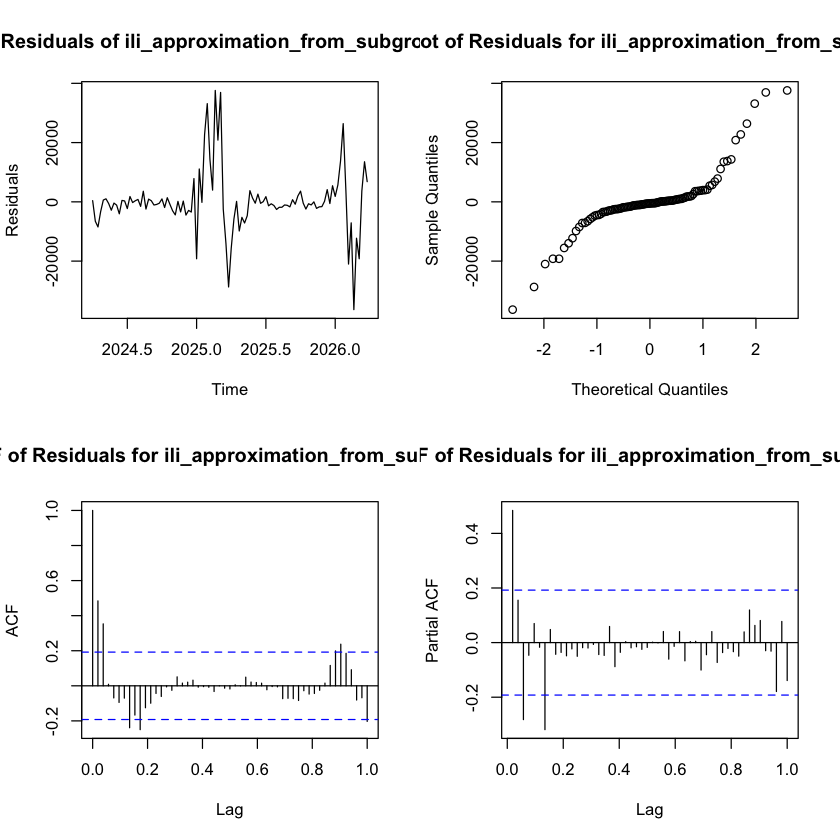

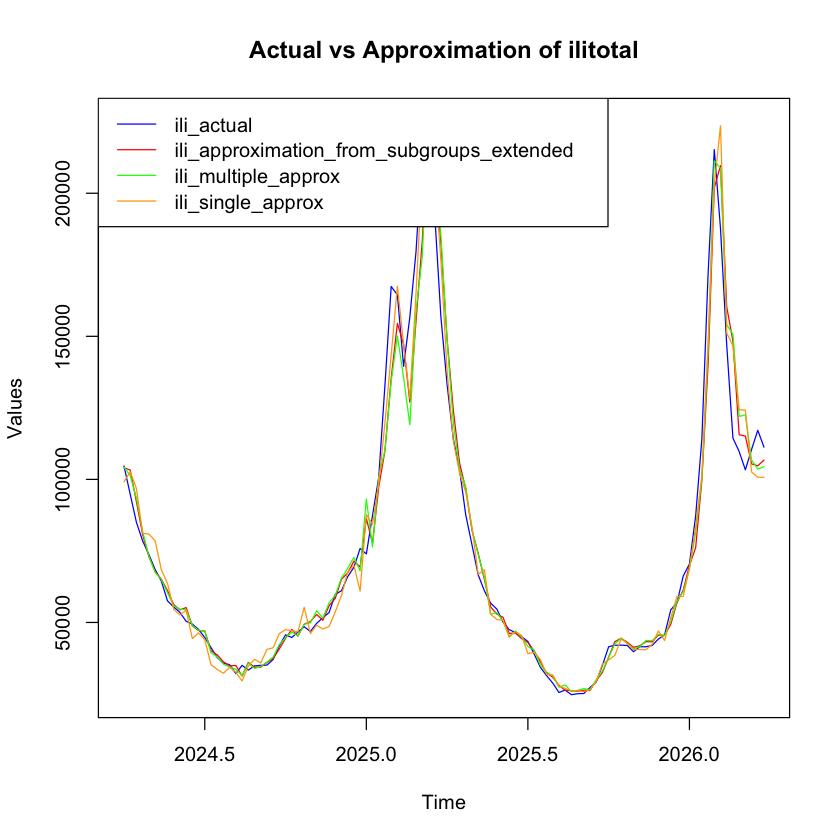

In [75]:
ili_approximation_from_subgroups <- fc_age_0_4$best_fc+fc_age_5_24$best_fc+fc_age_25_64$best_fc+fc_age_65$best_fc
ili_approximation_from_subgroups_extended <- fc_age_0_4$best_fc+fc_age_5_24$best_fc+fc_age_25_49$best_fc+fc_age_50_64$best_fc+fc_age_65$best_fc # notice we dont want age_25_65
ilitotal_holdout <- split_data(df$ilitotal)$holdout

print_rmse(sqrt(mean((expm1(ilitotal_holdout) - ili_approximation_from_subgroups)^2)), "ilitotal", c("age_0_4", "age_5_24", "age_25_64", "age_65"))
print_rmse(sqrt(mean((expm1(ilitotal_holdout) - ili_approximation_from_subgroups_extended)^2)), "ilitotal", c("age_0_4", "age_5_24", "age_25_49", "age_50_64", "age_65"))
plotresidues(expm1(ilitotal_holdout)-ili_approximation_from_subgroups, "ili_approximation_from_subgroups")
# plot(ilitotal_holdout*0+ili_approximation_from_subgroups,type='l', main="Approximation of ilitotal from subgroups", ylab="Approximation", xlab="Time")
# plot(expm1(ilitotal_holdout))
par(mfrow = c(1, 1))
ts.plot(expm1(ilitotal_holdout),ili_approximation_from_subgroups_extended, ili_approximation_from_subgroups,ilitotal_fc, col=c("blue", "red","green","orange"), main="Actual vs Approximation of ilitotal", ylab="Values", xlab="Time")
legend("topleft", 
       legend = c("ili_actual","ili_approximation_from_subgroups_extended", "ili_multiple_approx", "ili_single_approx"), 
       col = c("blue", "red", "green", "orange"), 
       lty = c(1, 1, 1))

[1] 10295.25
[1] 9823.528
[1] 8997.344


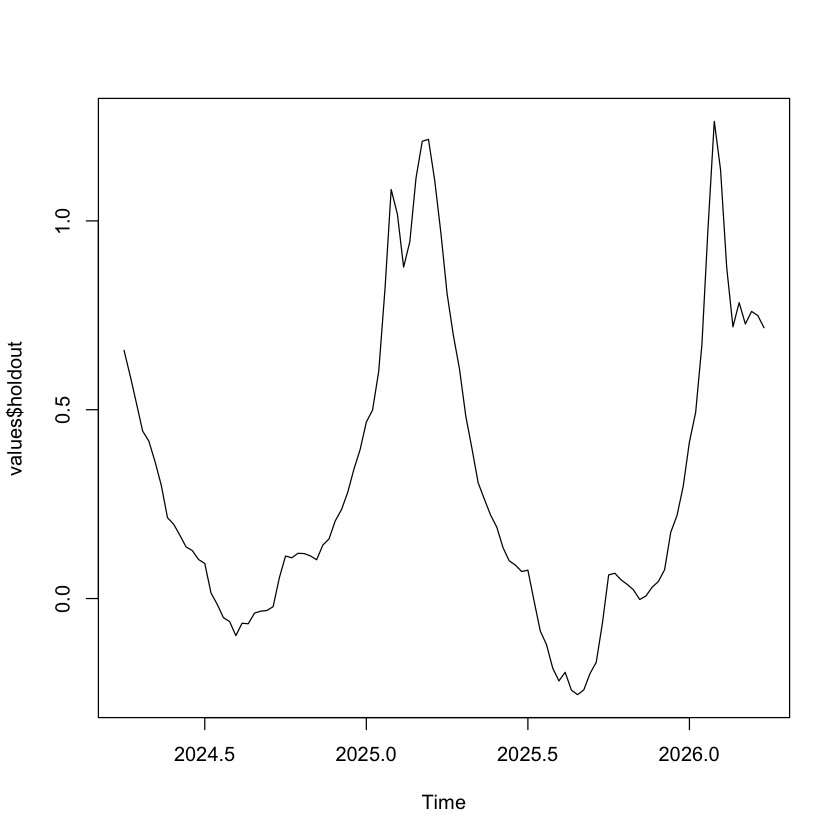

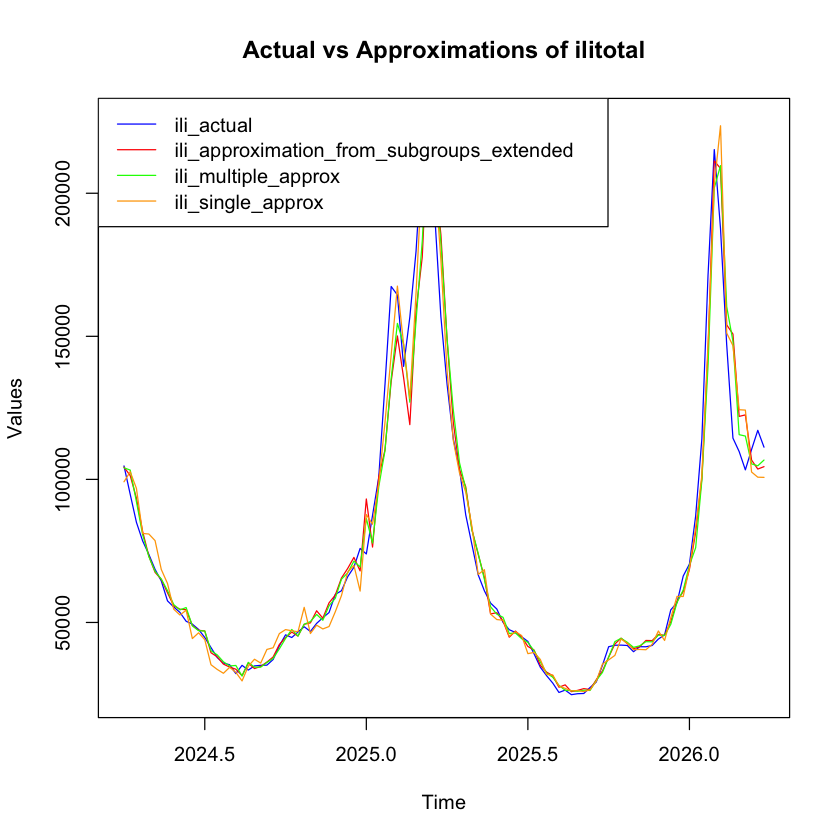

In [76]:

df <- read.csv("data/fluview_clean/ilinet_final.csv")
# ili_total <- split_data(df$ilitotal)

rmse_multi_seasonal_external_reg <- sqrt(mean((expm1(ilitotal_holdout) - ili_approximation_from_subgroups)^2))
rmse_multi_seasonal_external_reg_extended <- sqrt(mean((expm1(ilitotal_holdout) - ili_approximation_from_subgroups_extended)^2))
rmse <- sqrt(mean((expm1(ilitotal_holdout) - ilitotal_fc)^2))
plot(values$holdout, type='l')

print(rmse_multi_seasonal_external_reg)
print(rmse_multi_seasonal_external_reg_extended)
print(rmse)

ts.plot(expm1(ilitotal_holdout), ili_approximation_from_subgroups,ili_approximation_from_subgroups_extended,ilitotal_fc, col=c("blue", "red","green","orange"), main="Actual vs Approximations of ilitotal", ylab="Values", xlab="Time")
legend("topleft", 
       legend = c("ili_actual","ili_approximation_from_subgroups_extended", "ili_multiple_approx", "ili_single_approx"), 
       col = c("blue", "red", "green", "orange"), 
       lty = c(1, 1, 1))

In [ ]:


# v <- arima(values$train, order = c(1, 1, 1),seasonal = list(order = c(1, 1, 0), period = 52))
# acf(fc_non_ilitotal)

## FC non_ilitotal

This is about trying to see if we can minimise non_ilitotal.

# Non_ili_total
Forcasting the non_ili_total since we can use this to get the unweighted percentage ili.

Complete:  100 % Best Orders: ar=c(0, 3, 1), i=c(1, 0, 0), ma=c(1, 0, 0) Best RMSE so far: 111126.105783833 


[1] 14.70284 14.71599 14.70626 14.69604 14.68856 14.69831 14.64710 14.69248
  [9] 14.70482 14.68309 14.74615 14.67955 14.67026 14.70455 14.62476 14.65407
 [17] 14.65061 14.65710 14.63163 14.61905 14.67991 14.64453 14.64358 14.66599
 [25] 14.64903 14.66373 14.65853 14.67391 14.66080 14.68993 14.70390 14.73418
 [33] 14.79437 14.76438 14.78383 14.80288 14.81309 14.82274 14.68368 14.87526
 [41] 14.67816 14.74695 14.77234 14.73494 14.70730 14.72285 14.69885 14.79158
 [49] 14.71408 14.81034 14.75170 14.74982 14.73289 14.74998 14.75433 14.76084
 [57] 14.75608 14.71845 14.84494 14.69417 14.71408 14.75159 14.77856 14.72117
 [65] 14.74929 14.68223 14.75611 14.67027 14.70346 14.72484 14.69842 14.68550
 [73] 14.70111 14.69520 14.72732 14.70818 14.72518 14.73262 14.72241 14.68764
 [81] 14.73849 14.73534 14.72467 14.80038 14.79082 14.76496 14.77628 14.75987
 [89] 14.73836 14.75599 14.74521 14.68523 14.68941 14.75698 14.75123 14.69406
 [97] 14.71154 14.69172 14.80302 14.71847 14.74114 14.66435 14.68947 14.73194

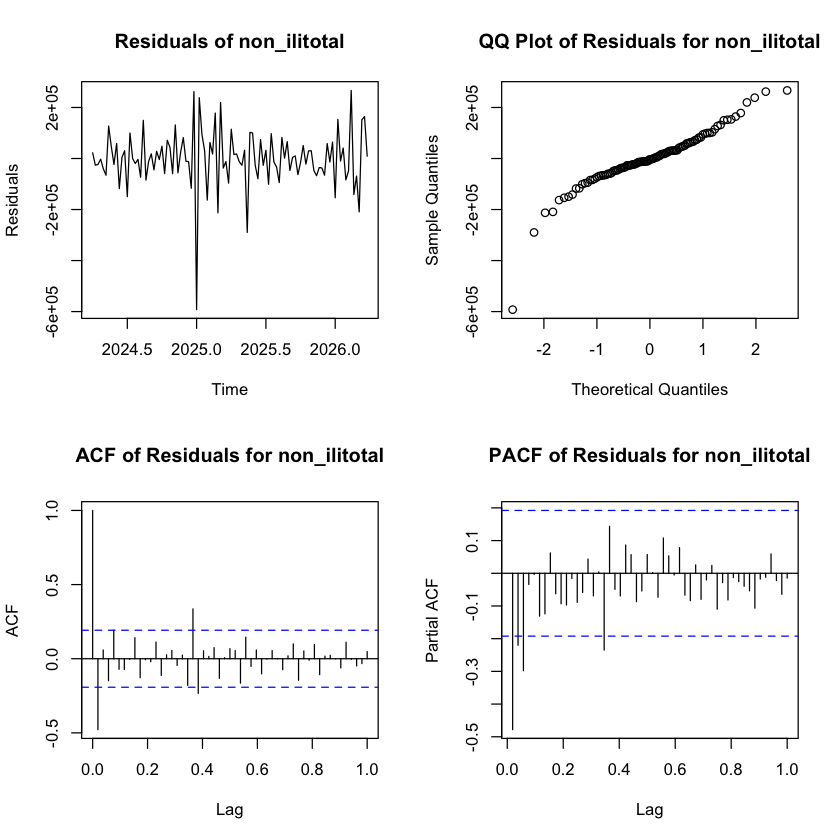

In [ ]:

initial_orders_non_ilitotal = list(ar=c(0, 3, 1), i=c(1, 0, 0), ma=c(1, 0, 0))

fc_non_ilitotal <- get_it("non_ilitotal", initial_orders_non_ilitotal, 2, 1)
fc_non_ilitotal_values <- fc_non_ilitotal$best_fc
fc_non_ilitotal_fit <- fc_non_ilitotal$fit

# Unweighted ILI_percentage

[1] "Total patients forecast RMSE: 142839.459382189"


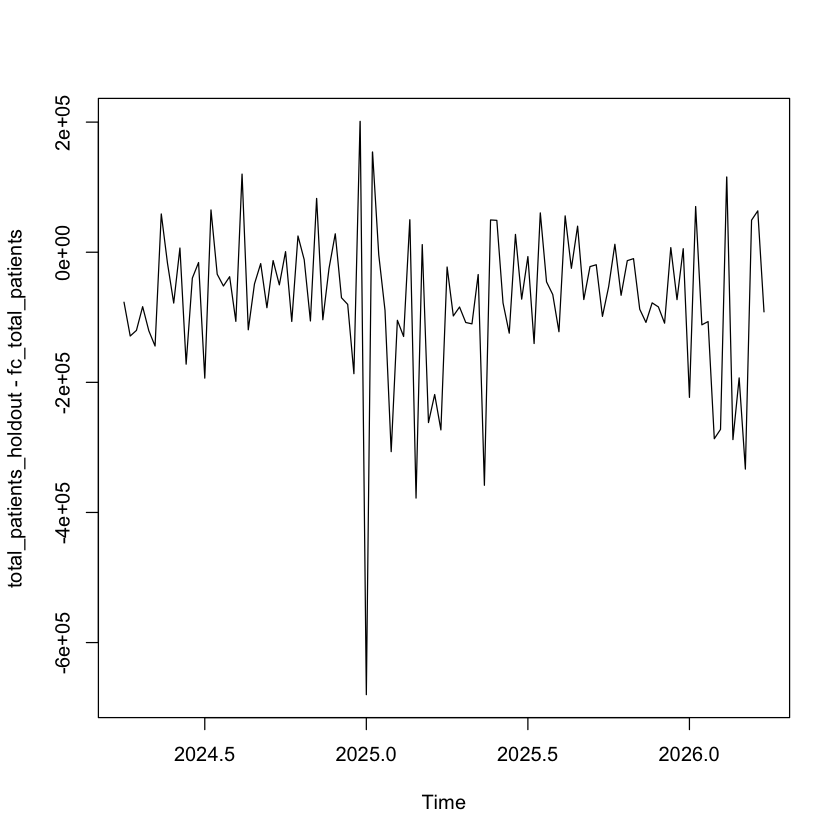

[1] "Unweighted percentage ratio RMSE: 0.328780760726501"


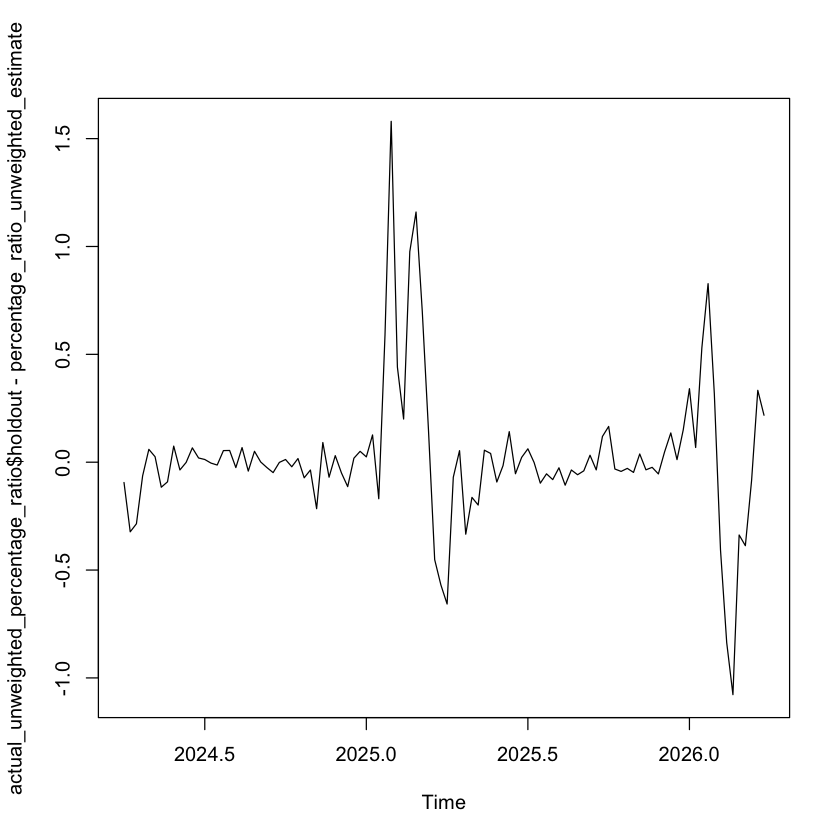

In [220]:

fc_total_patients <- ilitotal_fc +fc_non_ilitotal$best_fc
total_patients_holdout <- split_data(total_patients)$holdout
rmse_total <- sqrt(mean((total_patients_holdout - fc_total_patients)^2))
print(paste("Total patients forecast RMSE:", rmse_total))
plot(total_patients_holdout - fc_total_patients)
# percentage_ratio <- ili
percentage_ratio_unweighted_estimate <- numeric(length = length(fc_total_patients))
if(any(fc_total_patients==0)){
    percentage_ratio_unweighted_estimate <- 0
} else {
    percentage_ratio_unweighted_estimate <- (ili_sus) / fc_total_patients*100
}

actual_unweighted_percentage_ratio <- split_data(df$percent_unweighted_ili)
plot(actual_unweighted_percentage_ratio$holdout-percentage_ratio_unweighted_estimate, type='l')

rmse_unweighted_percentage_ratio <- sqrt(mean((actual_unweighted_percentage_ratio$holdout - percentage_ratio_unweighted_estimate)^2))
print(paste("Unweighted percentage ratio RMSE:", rmse_unweighted_percentage_ratio))


## Weighted ILI_percentage

In [ ]:
initial_orders_percent_weighted_ili = list(ar=c(4, 3, 3), i=c(0, 1, 0), ma=c(6, 1, 4))

fc_percent_weighted_ili <- get_it("percent_weighted_ili", initial_orders_percent_weighted_ili, 2, 0,inverse_transformation = function(x)x)

fc_percent_weighted_ili_values <- fc_percent_weighted_ili$best_fc
fc_percent_weighted_ili_fit <- fc_percent_weighted_ili$fit

In [96]:
all_columns = c("single","external","external_extended")

msarima_rmse_results <- data.frame(variable = all_columns, rmse = c(rmse,rmse_multi_seasonal_external_reg,rmse_multi_seasonal_external_reg_extended))

msarima_forecasts_list$single <- ilitotal_fc
msarima_forecasts_list$external <-  ili_approximation_from_subgroups
msarima_forecasts_list$external_extended <- ili_approximation_from_subgroups_extended

msarima_forecasts_list <- data.frame(
    holdout=expm1(ilitotal_holdout),
    single=ilitotal_fc,
    external = ili_approximation_from_subgroups,
    external_extended =ili_approximation_from_subgroups_extended
)

write.csv(msarima_forecasts_list, "./forecasting/msarima_forecasts.csv", row.names = FALSE)
write.csv(msarima_rmse_results, "./forecasting/msarima_rmse.csv", row.names = FALSE)


# format_msarima(ilitotal_model$best_orders)
# format_msarima(fc_age_0_4$best_orders)
# format_msarima(fc_age_5_24$best_orders)
# format_msarima(fc_age_25_64$best_orders)
# format_msarima(fc_age_65$best_orders)
# format_msarima(fc_age_25_49$best_orders)
# format_msarima(fc_age_50_64$best_orders)
# fc_age_5_24$best_rmse
# ili_approximation_from_subgroups_extended
rmse
rmse_multi_seasonal_external_reg
rmse_multi_seasonal_external_reg_extended

[1] 8997.344

[1] 10295.25

[1] 9823.528

In [125]:
save_img(function(){
    ts.plot(expm1(ilitotal_holdout), ilitotal_fc,ili_approximation_from_subgroups,ili_approximation_from_subgroups_extended,
     lty = c(1, 2, 2,2),
     col=c("black", "red", "blue", "darkgreen"),lwd = 2,  main="Actual vs Approximations of ilitotal", ylab="Values", xlab="Time")
legend("topleft", 
       legend = c("ili_total","MS ARIMA(2,0,3)(2,0,2)_{19}(3,1,1)_{52}","MS ARIMA (Subgroups)", "MS ARIMA (Subgroups Extended)" ), 
       col = c("black", "red", "blue", "darkgreen"),
       lty = c(1, 2, 2, 2))
       lwd=2
},"msarima_forecast_comparison.png",width = 800, height = 600)

In [134]:
residuals <- expm1(ilitotal_holdout) - ilitotal_fc
new_fit <- msarima(
            df$ilitotal,
            orders = ilitotal_model$best_orders,
            lags = c(1, 52, 19),
        )



In [142]:
source("residual_checks.r")
par(mfrow=c(1,1))
# residuals_diagnostics(new_fit,residuals)

save_img(function(){plotresidues(residuals,"MS ARIMA single")},name = "msarima_single_residuals.png", width = 800, height = 800)

agg_record_f08917a4ed90 
                      2